In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Required Functions: Static Tolling

### Revenue

In [ ]:
def revenue_static_toll(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L):
  '''
  Computes the revenue for any static toll tau and parameter values
  '''
  if tau > z_T - z_C: #Users only use transit at equilibrium
    revenue = 0
  elif tau >= z_T - z_C - (num_users * e * L) / (service_rate * (e + L)): #Users use a mix of transit and car at equilibrium
    revenue = service_rate * tau * ( num_users/arrival_rate +  ((z_T - z_C - tau)*(e+L)/(e*L)) * (1 - service_rate/arrival_rate))
  else: #Toll is small enough that all people use cars at equilibrium
    revenue = tau * num_users

  return revenue

In [ ]:
def static_optimal_toll(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
  '''
  Computes the optimal static toll and revenue for any value of z_T - z_C
  '''
  threshold = (num_users * e * L)/((arrival_rate - service_rate) * (e + L))
  if z_T - z_C <= threshold:
    opt_static_toll = z_T - z_C
  else:
    opt_static_toll = max((z_T - z_C)/2 + threshold/2, z_T - z_C - num_users * e * L / (service_rate * (e + L)))

  static_toll_rev = revenue_static_toll(opt_static_toll, z_T, z_C, num_users, arrival_rate, service_rate, e, L)

  return opt_static_toll, static_toll_rev

In [ ]:
def static_sc_opt_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the revenue for the system cost minimizing static toll
    '''
    T_C = (num_users * e * L)/(service_rate * (e + L))
    if service_rate / arrival_rate >= 2/3:
        if z_T - z_C - T_C <= 0:
            tau_val_true = z_T - z_C
        else:
            if (z_T - z_C - (T_C/2)) * ((z_T - z_C) * ((service_rate * (e + L)/(e * L)) * (2 - 2 * service_rate/arrival_rate)) - 2 * num_users + num_users * service_rate/arrival_rate) <= 0:
                tau_val_true = z_T - z_C
            else:
                tau_val_true = max(0, z_T - z_C - T_C)
    else:
        tau_val = (T_C * (service_rate / arrival_rate) + (z_T - z_C) * (1 - 2 * (service_rate / arrival_rate))) / (2 - 3 * (service_rate / arrival_rate))
        if tau_val <= 0:
            tau_val_true = max(0, z_T - z_C - T_C)
        elif tau_val >= z_T - z_C:
            tau_val_true = z_T - z_C
        else:
            tau_val_true = max(tau_val, z_T - z_C - T_C)

    revenue = revenue_static_toll(tau_val_true, z_T, z_C, num_users, arrival_rate, service_rate, e, L)

    return revenue, tau_val_true

### System Cost

In [ ]:
def total_system_cost_only_transit(z_T, num_users):
    """
    Computes total system cost when the static toll is such that only
    transit is used at equilibrium
    """

    return z_T * num_users

In [ ]:
def total_system_cost_only_car(tau, z_C, num_users, arrival_rate, service_rate, e, L):
    """
    Computes total system cost when the static toll is such that only
    car is used at equilibrium
    """

    term1 = z_C * num_users
    term2 = ((num_users ** 2) * e * L) / (2 * service_rate * (e + L)) * (1.0 - (service_rate / arrival_rate))
    term3 = ((num_users ** 2) * e * L) / (2 * service_rate * (e + L))

    return term1 + term2 + term3

In [ ]:
def total_system_cost_car_transit(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    """
    Computes total system cost when the static toll is such that both car and
    transit are used at equilibrium
    """
    tau = np.asarray(tau)

    # Common pieces
    delta = z_T - z_C - tau                                  # (z_T - z_C - τ)
    denom_cap = (num_users * e * L) / (service_rate * (e + L))  # Λ e L / (μ (e + L))
    one_over_e_plus_L = (1.0 / e) + (1.0 / L)
    one_minus_mu_over_lambda = 1.0 - (service_rate / arrival_rate)

    # Terms from the image formula
    term1 = z_T * (1.0 - (delta / denom_cap)) * num_users * one_minus_mu_over_lambda

    term2 = z_C * (
        service_rate * delta * one_over_e_plus_L
        + (1.0 - (delta / denom_cap)) * num_users * (service_rate / arrival_rate)
    )

    term3 = (
        service_rate * (delta ** 2) / 2.0
        * one_minus_mu_over_lambda * one_over_e_plus_L
    )

    term4 = delta * (
        (1.0 - (delta / denom_cap)) * num_users * (service_rate / arrival_rate)
        + service_rate * delta / 2.0 * one_over_e_plus_L
    )

    return term1 + term2 + term3 + term4

In [ ]:
def total_system_cost_static(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    """
    Computes the total system cost given a toll tau under the specified
    parameters
    """

    if tau > z_T - z_C: #Users only use transit at equilibrium
      system_cost = total_system_cost_only_transit(z_T, num_users)
    elif tau >= z_T - z_C - (num_users * e * L) / (service_rate * (e + L)): #Users use a mix of transit and car at equilibrium
      system_cost = total_system_cost_car_transit(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L)
    else: #Toll is small enough that all people use cars at equilibrium
      system_cost = total_system_cost_only_car(tau, z_C, num_users, arrival_rate, service_rate, e, L)

    return system_cost

## Required Functions Dynamic Tolling

### Revenue

In [ ]:
def dynamic_optimal_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
  '''
  Computes the optimal dynamic revenue for any set of parameter values
  '''
  T_C = (num_users * e * L)/(service_rate * (e + L))

  if z_T - z_C <= T_C * arrival_rate /(arrival_rate - service_rate):
    revenue = (z_T - z_C) * num_users * service_rate/arrival_rate + ((z_T - z_C)**2)* service_rate * (e+L)/(2*e*L) * ((1 - service_rate/arrival_rate)**2)
  else:
    revenue = (z_T - z_C) * num_users - (((num_users)**2) / (2 * service_rate)) * (e * L)/(e + L)

  return revenue

In [ ]:
def dynamic_opt_fraction(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the optimal fraction of time the toll is set to z_T - z_C under
    the dynamic revenue optimal tolling policy
    '''

    return max( 1 - (z_T - z_C) * service_rate * (e + L) / (num_users * e * L) * (1 - (service_rate / arrival_rate)) , 0)

In [ ]:
def dynamic_revenue_variable_lambda(z_T, z_C, num_users, arrival_rate, service_rate, e, L, frac):
    '''
    Computes the revenue corresponding to a dynamic tolling policy that knows
    the true values of e, L, z_T, z_C, service_rate, but has a mis-specified
    number of users Lambda

    Here frac is the fraction of time spent with a toll of z_T - z_C under a
    dynamic tolling policy with a mis-specified Lambda
    '''

    term1 = (z_T - z_C) * ((frac * num_users * service_rate / arrival_rate) + (1 - frac) * num_users)
    term2 = - ((num_users ** 2) * e * L) / (2 * service_rate * (e + L)) * ((1 - frac)**2)

    return term1 + term2

In [ ]:
def sc_opt_dyn_toll_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the revenue corresponding to the dynamic system cost minimizing
    tolling policy
    '''

    T_C = (num_users * e * L)/(service_rate * (e + L))

    if z_T - z_C <= T_C:
        term1 = (service_rate / 2) * ((z_T - z_C)**2) * (1/e + 1/L)
        term2 = (z_T - z_C) * (1 - ((z_T - z_C)/T_C)) * num_users * service_rate / arrival_rate
        revenue = term1 + term2
    else:
        revenue = (z_T - z_C) * num_users - (((num_users)**2) / (2 * service_rate)) * (e * L)/(e + L)

    return revenue

### System Cost

In [ ]:
def system_opt_cost(z_C, z_T, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the system optimum cost
    '''
    T_C = (num_users * e * L)/(service_rate * (e + L))

    if z_T - z_C <= T_C:
      baseline_cost = z_C * num_users * (service_rate / arrival_rate) + z_T * num_users * (1 - (service_rate / arrival_rate))
      correction_term = (1 - (service_rate / arrival_rate)) * (service_rate * (e + L) / (2 * e * L)) * ((z_T - z_C)**2)

      system_cost = baseline_cost - correction_term

    else:
      #everyone users a car at the system optimum solution
      system_cost = z_C * num_users + (e * L) / (2 * (e + L)) * (num_users**2) * (1/service_rate - 1/arrival_rate)

    return system_cost

In [ ]:
def system_cost_dynamic(z_C, z_T, num_users, arrival_rate, service_rate, e, L, frac):
    '''
    Computes the system cost corresponding to the dynamic revenue tolling
    policy where frac is the fraction of time spent with a toll of z_T - z_C
    under a dynamic tolling policy with a mis-specified Lambda
    '''

    term1 = z_T * (frac * num_users * (1 - service_rate / arrival_rate))
    term2 = z_C * ((frac * num_users * service_rate / arrival_rate) + (1 - frac) * num_users)
    term3 = ((num_users ** 2) * e * L) / (2 * service_rate * (e + L)) * ((1 - frac)**2) * (1 - service_rate / arrival_rate)

    return term1 + term2 + term3

#### Theory Bounds

In [ ]:
def theory_bound(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
  '''
  Computes the theoretical bound for the ratio of the revenue of the
  optimal static toll to that of the optimal dynamic toll for any set of
  parameter values
  '''
  threshold = (num_users * e * L)/((arrival_rate - service_rate) * (e + L))
  if z_T - z_C >= threshold:
    if z_T - z_C <= num_users * e * L /(e + L) * (1 / (arrival_rate - service_rate) + 2 / service_rate):
      bd = min(1/(2*(1 - service_rate/arrival_rate)), 1/2 + threshold/(4 * (z_T - z_C)))
    else:
      bd = 2/3

  else:
    bd = 2/(3 - service_rate/arrival_rate)

  return bd

In [ ]:
def theory_bound_sc(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
  '''
  Computes the theoretical bound for the ratio of the system cost of the
  optimal static toll to that of the minimum system cost for any set of
  parameter values
  '''
  T_C = (num_users * e * L)/(service_rate * (e + L))
  if z_T - z_C <= T_C:
    bd = 2
  else:
    threshold = (num_users * e * L)/((arrival_rate - service_rate) * (e + L)) * ( (2 * arrival_rate - service_rate) / service_rate )
    if z_T - z_C <= threshold:
      bd = 2 + 2 / (1 - (service_rate / arrival_rate))
    else:
      bd = 1 + 1 / (1 - (service_rate / arrival_rate))

  return bd

## Required Functions: Step Tolling

### Revenue

In [ ]:
def dynamic_two_step_toll(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
    '''
    Computes the lower value of the toll under any dynamic tolling policy
    '''

    return ((z_T - z_C) / 2) * (1 + (service_rate / arrival_rate))

In [ ]:
def dynamic_step_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
  '''
  Computes the revenue for a discretized step toll any set of parameter values
  '''
  T_C = (num_users * e * L)/(service_rate * (e + L))
  tau = dynamic_two_step_toll(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
  if z_T - z_C <= T_C + tau:
    term1 = (z_T - z_C) * num_users * (service_rate / arrival_rate)
    term2 = (((z_T - z_C)**2) / 4) * ((1 - (service_rate / arrival_rate))**2) * ((e + L)/(e * L)) * service_rate
    revenue = term1 + term2
  else:
    revenue = revenue_static_toll(tau, z_T, z_C, num_users, arrival_rate, service_rate, e, L)

  return revenue

In [ ]:
def dynamic_average_twostep_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L):
  '''
  Computes the revenue for a discretized step toll where we take the toll
  as the average of the left and right end points in the sloped region for
  any set of parameter values
  '''
  T_C = (num_users * e * L)/(service_rate * (e + L))
  f = dynamic_opt_fraction(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
  tau = z_T - z_C - ((e * L) / (2 * (e + L))) * (1 - f) * num_users / service_rate

  term1 = (z_T - z_C) * num_users * (service_rate / arrival_rate) * f
  term2 = tau * (1 - f) * (num_users / 2) * (1 + (service_rate / arrival_rate))
  revenue = term1 + term2

  return revenue

In [ ]:
def dynamic_lb_nstep_revenue(z_T, z_C, num_users, arrival_rate, service_rate, e, L, num_steps):
  '''
  Computes the revenue for a discretized step toll where we take the toll
  as the lower bound of the different steps in the sloped region for any set of
  parameter values
  '''
  f = dynamic_opt_fraction(z_T, z_C, num_users, arrival_rate, service_rate, e, L)

  term1 = (z_T - z_C) * num_users * (service_rate / arrival_rate) * f
  term2 = 0
  for i in range(num_steps - 1):
      tau = z_T - z_C - ((i + 1)/(num_steps - 1)) * ((e * L) / (e + L)) * (1 - f) * num_users / service_rate
      term2 += tau * (1 - f) * num_users * (1/(num_steps - 1))

  revenue = term1 + term2

  return revenue

### System Cost

In [ ]:
def dynamic_lb_nstep_system_cost(z_T, z_C, num_users, arrival_rate, service_rate, e, L, num_steps):
  '''
  Computes the system cost for a discretized step toll where we take the toll
  as the lower bound of the different steps in the sloped region for any set of
  parameter values
  '''
  f = dynamic_opt_fraction(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
  #print(f)
  term1 = z_T * num_users * f * (1 - (service_rate / arrival_rate))
  term2 = z_C * num_users * (1 - f) + z_C * num_users * f * (service_rate / arrival_rate)
  term3 = ((num_users ** 2) * e * L) / (2 * service_rate * (e + L)) * ((1 - f)**2) * (1 - service_rate / arrival_rate)
  term4 = ((e * L) / (e + L)) * ((1 - f) * num_users / service_rate) * (1/((num_steps - 1)*2)) * ((1 - f) * num_users)
  #print(term4)
  system_cost = term1 + term2 + term3 + term4

  return system_cost

## Experiments

### Experiment 1: Toll Values Under Static Tolls

In [ ]:
#Parameter Initialization

service_rate = 9600 # $\mu$
e = 0.61 # Relative value of being early
L = 2.4 # Relative value of being late
c_w = 22 # $/hr cost of waiting
num_users = 70000
arrival_rate = num_users / 5

bart_avg_fare = 6.14
avg_walking_time = 2/6
half_avg_headway = 10/60
avg_trip_time = 32 / 60

def bart_cost_(multiplier):
  '''
  Returns the cost of using bart given a discomfort multiplier
  '''

  bart_cost = bart_avg_fare + ( avg_walking_time + half_avg_headway + avg_trip_time ) * c_w * multiplier

  return bart_cost

avg_tt = 21.02268493/60
parking_fee = 30
car_cost = avg_tt * c_w + parking_fee
z_C = car_cost / c_w

In [ ]:
discomfort_multiplier = np.linspace(1, 30, 1000)
toll_array = []
z_T_z_C_array = []

for discomfort_mult_val in discomfort_multiplier:

  z_T = bart_cost_(discomfort_mult_val) / c_w
  if z_T < z_C:
    tau_star = 0
  else:
    tau_star, rev_star = static_optimal_toll(z_T, z_C, num_users, arrival_rate, service_rate, e, L)
  toll_array.append(tau_star * c_w)
  z_T_z_C_array.append(z_T - z_C)

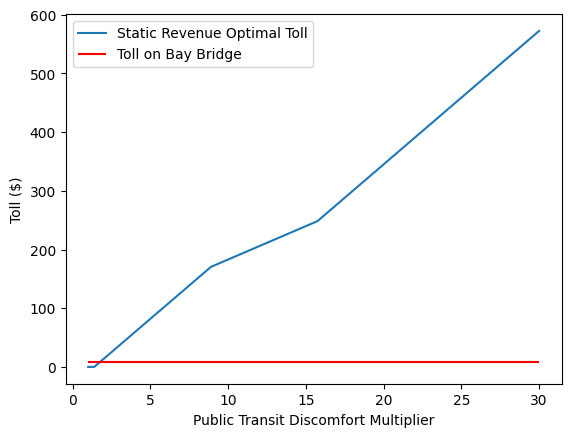

In [ ]:
plt.plot(discomfort_multiplier, toll_array)
plt.hlines(
                y=8,            # y-value of the line
                xmin=1,         # start x
                xmax=30,       # end x
                colors="red",   # line color
                #linestyles="-",# dashed style
                label="Toll on Bay Bridge"
            )
plt.xlabel('Public Transit Discomfort Multiplier')
plt.ylabel('Toll ($)')
plt.legend(['Static Revenue Optimal Toll', 'Toll on Bay Bridge'])

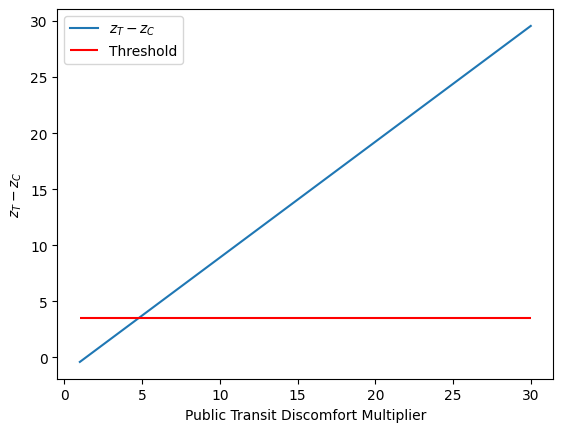

In [ ]:
thresh = num_users * e * L / (service_rate * (e + L))
plt.plot(discomfort_multiplier, z_T_z_C_array)
plt.hlines(
                y=thresh,            # y-value of the line
                xmin=1,         # start x
                xmax=30,       # end x
                colors="red",   # line color
                #linestyles="-",# dashed style
                label="Threshold"
            )
plt.xlabel('Public Transit Discomfort Multiplier')
plt.ylabel('$z_T - z_C$')
plt.legend(['$z_T - z_C$', 'Threshold'])

### Experiment 2: Revenue Comparisons under Static Tolls

Text(0, 0.5, 'Ratio of Revenues')

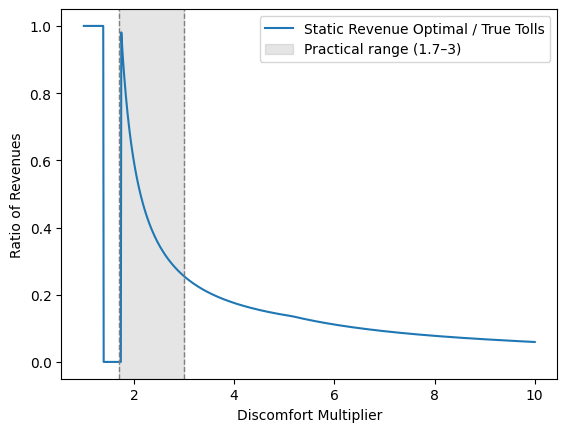

In [ ]:
discomfort_multiplier = np.linspace(1, 10, 1000)
rev_array = []
rev_current = []
rev_ratio = []
z_T_z_C_array = []

for discomfort_mult_val in discomfort_multiplier:

  z_T = bart_cost_(discomfort_mult_val) / c_w
  if z_T < z_C:
    tau_star = 0
    rev_star = 0
  else:
    tau_star, rev_star = static_optimal_toll(z_T, z_C, num_users, arrival_rate, service_rate, e, L)

  rev_current_val = revenue_static_toll(8/c_w, z_T, z_C, num_users, arrival_rate, service_rate, e, L)
  #print(rev_current_val, rev_star)
  rev_array.append(rev_star * c_w)
  rev_current.append(rev_current_val * c_w)

  if z_T < z_C:
    rev_ratio.append(1)
  else:
    rev_ratio.append(rev_current_val/rev_star)
  z_T_z_C_array.append(z_T - z_C)

plt.plot(discomfort_multiplier, rev_ratio, label = 'Static Revenue Optimal / True Tolls')
plt.axvspan(1.7, 3, color='gray', alpha=0.2, label="Practical range (1.7–3)")
plt.axvline(1.7, color='gray', linestyle='--', linewidth=1)
plt.axvline(3, color='gray', linestyle='--', linewidth=1)
plt.legend()
plt.xlabel('Discomfort Multiplier')
plt.ylabel('Ratio of Revenues')

Text(0, 0.5, 'Revenue ($)')

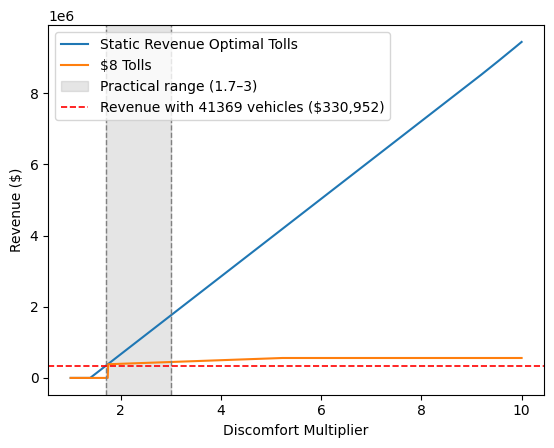

In [ ]:
plt.plot(discomfort_multiplier, rev_array, label = 'Static Revenue Optimal Tolls')
plt.plot(discomfort_multiplier, rev_current, label = '$8 Tolls')
plt.axvspan(1.7, 3, color='gray', alpha=0.2, label="Practical range (1.7–3)")
plt.axvline(1.7, color='gray', linestyle='--', linewidth=1)
plt.axvline(3, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=330952, color='red', linestyle='--', linewidth=1.2, label='Revenue with 41369 vehicles ($330,952)')

plt.legend()
plt.xlabel('Discomfort Multiplier')
plt.ylabel('Revenue ($)')

In [ ]:
z_T = bart_cost_(2.15) / c_w
rev_current_val = revenue_static_toll(8/c_w, z_T, z_C, num_users, arrival_rate, service_rate, e, L)
rev_current_val * c_w

404997.19349177706

### Experiment 3: Revenue Comparison Between Static and Dynamic Revenue Optimal Tolls

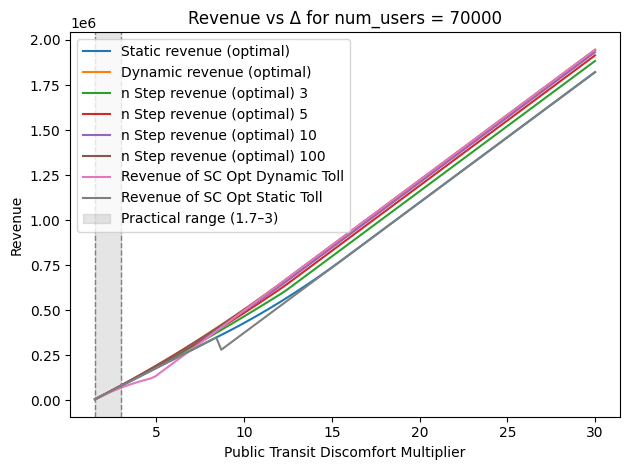

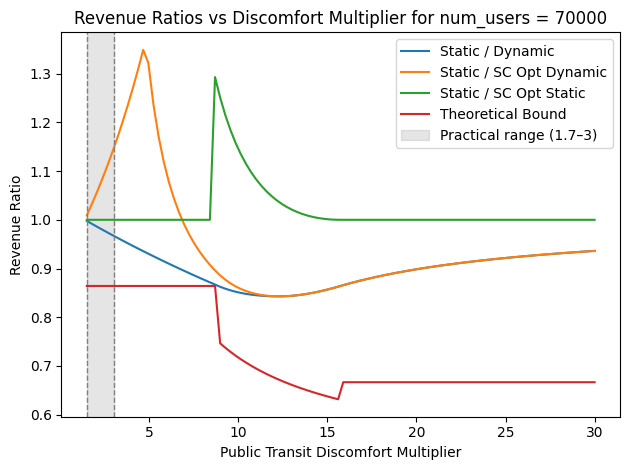


num_users = 70000
  Δ=1.5: static=4.78e+07, dynamic=4.793e+07, step=4.05e+07, static/dynamic=0.997, static/step=1.18
  Δ=15.9: static=4.78e+07, dynamic=4.793e+07, step=4.05e+07, static/dynamic=0.997, static/step=1.18
  Δ=30.0: static=4.78e+07, dynamic=4.793e+07, step=4.05e+07, static/dynamic=0.997, static/step=1.18


In [ ]:
# ===========================
# 1) USER-SET PARAMETERS
# ===========================
# Fixed primitives (EDIT as needed)
z_C = car_cost / c_w
service_rate = 9600
e = 0.61
L = 2.4

# Three values of num_users to compare (EDIT as needed)
num_users_list = [70000]#[50000, 70000, 100000]

# Sweep for z_T - z_C (Δ), i.e., the toll level difference
z_T_multiplier = np.linspace(1.5, 30, 100)  # (EDIT resolution/range as desired)

# ===========================
# 2) DRIVER
# ===========================
def safe_ratio(num, den):
    """Return num/den with safe handling of zeros (NaN where den==0)."""
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.full_like(num, np.nan, dtype=float)
    mask = den != 0
    out[mask] = num[mask] / den[mask]
    return out

for n_users in num_users_list:
    # Containers
    arrival_rate = n_users / 5

    rev_static = np.zeros_like(z_T_multiplier, dtype=float)
    rev_dynamic = np.zeros_like(z_T_multiplier, dtype=float)
    rev_step    = np.zeros_like(z_T_multiplier, dtype=float)
    rev_step2 = np.zeros_like(z_T_multiplier, dtype=float)
    rev_nstep2 = np.zeros_like(z_T_multiplier, dtype=float)
    rev_nstep3 = np.zeros_like(z_T_multiplier, dtype=float)
    rev_nstep5 = np.zeros_like(z_T_multiplier, dtype=float)
    rev_nstep10 = np.zeros_like(z_T_multiplier, dtype=float)
    rev_nstep100 = np.zeros_like(z_T_multiplier, dtype=float)
    rev_sc_opt = np.zeros_like(z_T_multiplier, dtype=float)
    rev_sc_opt_static = np.zeros_like(z_T_multiplier, dtype=float)
    theory_bd = np.zeros_like(z_T_multiplier, dtype=float)

    for i, z_diff in enumerate(z_T_multiplier):
        # For each Δ, set z_T = z_C + Δ (keeping z_C fixed, as requested)
        z_T = bart_cost_(z_diff) / c_w

        # --- Static: get optimal static toll and associated revenue ---
        # static_optimal_toll returns (tau_star, revenue_star)
        _tau_star, static_revenue_star = static_optimal_toll(
            z_T, z_C, n_users, arrival_rate, service_rate, e, L
        )
        rev_static[i] = static_revenue_star

        # --- Dynamic: optimal dynamic revenue for (z_T, z_C, ...) ---
        dyn_revenue_star = dynamic_optimal_revenue(
            z_T, z_C, n_users, arrival_rate, service_rate, e, L
        )
        rev_dynamic[i] = dyn_revenue_star

        # --- Step (two-step) policy revenue ---
        # If you want the actual step parameters, you can also call dynamic_two_step_toll(...)
        # Here we plot revenue via dynamic_step_revenue as requested.
        step_revenue = dynamic_step_revenue(
            z_T, z_C, n_users, arrival_rate, service_rate, e, L
        )
        rev_step[i] = step_revenue

        step_revenue_2 = dynamic_average_twostep_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        rev_step2[i] = step_revenue_2

        nstep_revenue_2 = dynamic_lb_nstep_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 2)
        rev_nstep2[i] = nstep_revenue_2

        nstep_revenue_3 = dynamic_lb_nstep_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 3)
        rev_nstep3[i] = nstep_revenue_3

        nstep_revenue_5 = dynamic_lb_nstep_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 5)
        rev_nstep5[i] = nstep_revenue_5

        nstep_revenue_10 = dynamic_lb_nstep_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 10)
        rev_nstep10[i] = nstep_revenue_10

        nstep_revenue_100 = dynamic_lb_nstep_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 100)
        rev_nstep100[i] = nstep_revenue_100

        rev_sc_opt_val = sc_opt_dyn_toll_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        rev_sc_opt[i] = rev_sc_opt_val

        rev_sc_opt_val_static, tau_val_static_sc_opt = static_sc_opt_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        rev_sc_opt_static[i] = rev_sc_opt_val_static

        theory_bd[i] = theory_bound(z_T, z_C, n_users, arrival_rate, service_rate, e, L)

    # Ratios
    ratio_static_over_dynamic = safe_ratio(rev_static, rev_dynamic)
    ratio_sc_opt_over_dynamic = safe_ratio(rev_sc_opt_static, rev_dynamic)
    ratio_opt_over_dynamic = safe_ratio(rev_sc_opt, rev_dynamic)
    ratio_static_over_step    = safe_ratio(rev_static, rev_step)
    ratio_static_over_step2    = safe_ratio(rev_static, rev_step2)
    ratio_static_over_nstep2    = safe_ratio(rev_static, rev_nstep2)
    ratio_static_over_nstep3    = safe_ratio(rev_static, rev_nstep3)
    ratio_static_over_nstep5    = safe_ratio(rev_static, rev_nstep5)
    ratio_static_over_nstep10    = safe_ratio(rev_static, rev_nstep10)
    ratio_static_over_nstep100    = safe_ratio(rev_static, rev_nstep100)
    ratio_static_over_sc_opt    = safe_ratio(rev_static, rev_sc_opt)
    ratio_static_over_sc_opt_static    = safe_ratio(rev_static, rev_sc_opt_static)

    # ===========================
    # 3) PLOTS (one chart per figure)
    # ===========================

    # Revenues: Static vs Dynamic vs Step
    plt.figure()
    plt.plot(z_T_multiplier, rev_static, label="Static revenue (optimal)")
    plt.plot(z_T_multiplier, rev_dynamic, label="Dynamic revenue (optimal)")
    #plt.plot(z_diff_grid, rev_step, label="Step revenue (optimal)")
    #plt.plot(z_diff_grid, rev_step2, label="Step revenue (optimal) 2")
    #plt.plot(z_T_multiplier, rev_nstep2, label="n Step revenue (optimal) 2")
    plt.plot(z_T_multiplier, rev_nstep3, label="n Step revenue (optimal) 3")
    plt.plot(z_T_multiplier, rev_nstep5, label="n Step revenue (optimal) 5")
    plt.plot(z_T_multiplier, rev_nstep10, label="n Step revenue (optimal) 10")
    plt.plot(z_T_multiplier, rev_nstep100, label="n Step revenue (optimal) 100")
    plt.plot(z_T_multiplier, rev_sc_opt, label="Revenue of SC Opt Dynamic Toll")
    plt.plot(z_T_multiplier, rev_sc_opt_static, label="Revenue of SC Opt Static Toll")

    plt.axvspan(1.5, 3, color='gray', alpha=0.2, label="Practical range (1.7–3)")
    plt.axvline(1.5, color='gray', linestyle='--', linewidth=1)
    plt.axvline(3, color='gray', linestyle='--', linewidth=1)

    plt.xlabel(r"Public Transit Discomfort Multiplier")
    plt.ylabel("Revenue")
    plt.title(f"Revenue vs Δ for num_users = {n_users}")
    plt.legend()
    plt.tight_layout()

    # Ratios: Static/Dynamic and Static/Step
    plt.figure()
    plt.plot(z_T_multiplier, ratio_static_over_dynamic, label="Static / Dynamic")
    #plt.plot(z_diff_grid, ratio_static_over_step, label="Static / Step")
    #plt.plot(z_diff_grid, ratio_static_over_step2, label="Static / Step 2")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep2, label="Static / n Step 2")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep3, label="Static / n Step 3")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep5, label="Static / n Step 5")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep10, label="Static / n Step 10")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep100, label="Static / n Step 100")
    plt.plot(z_T_multiplier, ratio_static_over_sc_opt, label="Static / SC Opt Dynamic")
    plt.plot(z_T_multiplier, ratio_static_over_sc_opt_static, label="Static / SC Opt Static")
    plt.plot(z_T_multiplier, theory_bd, label = 'Theoretical Bound')

    plt.axvspan(1.5, 3, color='gray', alpha=0.2, label="Practical range (1.7–3)")
    plt.axvline(1.5, color='gray', linestyle='--', linewidth=1)
    plt.axvline(3, color='gray', linestyle='--', linewidth=1)

    plt.xlabel(r"Public Transit Discomfort Multiplier")
    plt.ylabel("Revenue Ratio")
    plt.title(f"Revenue Ratios vs Discomfort Multiplier for num_users = {n_users}")
    plt.legend()
    plt.tight_layout()

plt.show()

# ===========================
# 4) (Optional) Quick text summary at a few Δ points
# ===========================
probe_idx = [0, len(z_T_multiplier)//2, -1]
for n_users in num_users_list:
    print(f"\nnum_users = {n_users}")
    for idx in probe_idx:
        Δ = z_T_multiplier[idx]
        z_T = bart_cost_(z_diff)
        _tau_star, s = static_optimal_toll(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        d  = dynamic_optimal_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        st = dynamic_step_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        r_sd = (s/d) if d != 0 else np.nan
        r_ss = (s/st) if st != 0 else np.nan
        print(f"  Δ={Δ:.1f}: static={s:.4g}, dynamic={d:.4g}, step={st:.4g}, "
              f"static/dynamic={r_sd:.3g}, static/step={r_ss:.3g}")


### Experiment 4: System Cost Comparison between Static and Dynamic Revenue Optimal Tolls

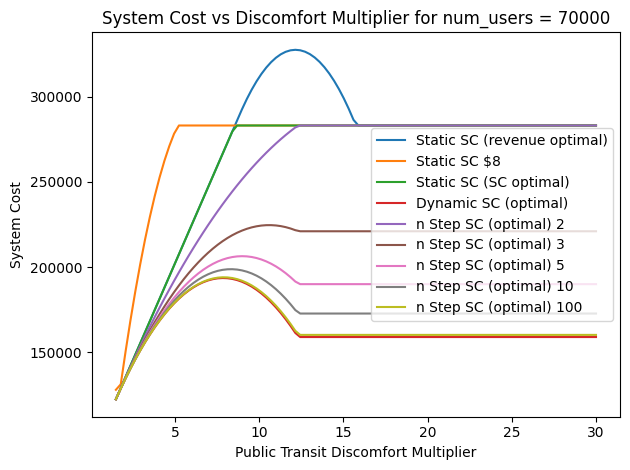

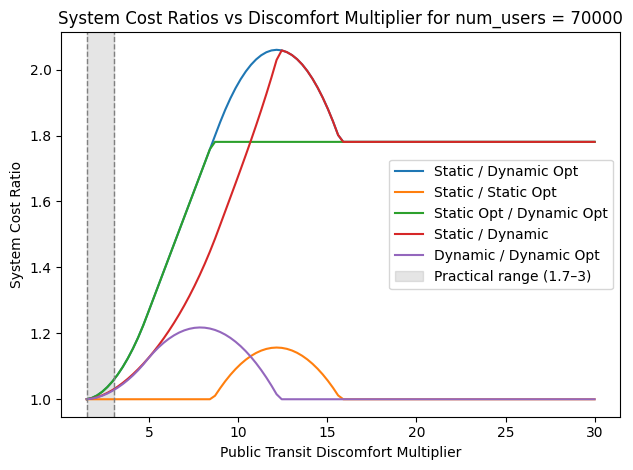


num_users = 70000
  Δ=1.5: static=7.2e+04, dynamic=7.419e+04, step=7.31e+04, static/dynamic=0.97, static/step=0.985
  Δ=15.9: static=8.643e+05, dynamic=9.884e+05, step=8.86e+05, static/dynamic=0.874, static/step=0.975
  Δ=30.0: static=1.852e+06, dynamic=1.976e+06, step=1.77e+06, static/dynamic=0.937, static/step=1.05


In [ ]:
# ===========================
# 1) USER-SET PARAMETERS
# ===========================
# Fixed primitives (EDIT as needed)
z_C = car_cost / c_w
service_rate = 9600
e = 0.61
L = 2.4

# Three values of num_users to compare (EDIT as needed)
num_users_list = [70000]#[50000, 68501, 100000]

# Sweep for z_T - z_C (Δ), i.e., the toll level difference
z_T_multiplier = np.linspace(1.5, 30, 100) # (EDIT resolution/range as desired)

# ===========================
# 2) DRIVER
# ===========================
def safe_ratio(num, den):
    """Return num/den with safe handling of zeros (NaN where den==0)."""
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.full_like(num, np.nan, dtype=float)
    mask = den != 0
    out[mask] = num[mask] / den[mask]
    return out

for n_users in num_users_list:
    # Containers
    arrival_rate = n_users / 5

    sc_static = np.zeros_like(z_T_multiplier, dtype=float)
    sc_true = np.zeros_like(z_T_multiplier, dtype=float)
    sc_dynamic = np.zeros_like(z_T_multiplier, dtype=float)
    sc_star = np.zeros_like(z_T_multiplier, dtype=float)
    sc_nstep2 = np.zeros_like(z_T_multiplier, dtype=float)
    sc_nstep3 = np.zeros_like(z_T_multiplier, dtype=float)
    sc_nstep5 = np.zeros_like(z_T_multiplier, dtype=float)
    sc_nstep10 = np.zeros_like(z_T_multiplier, dtype=float)
    sc_nstep100 = np.zeros_like(z_T_multiplier, dtype=float)
    sc_static_opt = np.zeros_like(z_T_multiplier, dtype=float)
    theory_bd_sc = np.zeros_like(z_T_multiplier, dtype=float)

    for i, z_diff in enumerate(z_T_multiplier):
        # For each Δ, set z_T = z_C + Δ (keeping z_C fixed, as requested)
        z_T = bart_cost_(z_diff) / c_w

        # --- Static: get optimal static toll and associated revenue ---
        # static_optimal_toll returns (tau_star, revenue_star)
        _tau_star, static_revenue_star = static_optimal_toll(
            z_T, z_C, n_users, arrival_rate, service_rate, e, L
        )
        sc_static[i] = total_system_cost_static(
                      _tau_star, z_T, z_C, n_users, arrival_rate, service_rate, e, L
                  )

        rev_sc_opt_val_static, tau_val_static_sc_opt = static_sc_opt_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        sc_static_opt[i] = total_system_cost_static(
                      tau_val_static_sc_opt, z_T, z_C, n_users, arrival_rate, service_rate, e, L
                  )

        # --- Dynamic: system cost of dynamic revenue optimal price for (z_T, z_C, ...) ---
        dyn_sc_star = system_opt_cost(z_C, z_T, n_users, arrival_rate, service_rate, e, L)

        sc_star[i] = dyn_sc_star


        frac = dynamic_opt_fraction(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        dyn_sc = system_cost_dynamic(z_C, z_T, n_users, arrival_rate, service_rate, e, L, frac)
        sc_dynamic[i] = dyn_sc

        sc_true[i] = total_system_cost_static(
                      8/c_w, z_T, z_C, n_users, arrival_rate, service_rate, e, L
                  )

        # --- Step (two-step) policy revenue ---
        # If you want the actual step parameters, you can also call dynamic_two_step_toll(...)
        # Here we plot revenue via dynamic_step_revenue as requested.


        nstep_sc_2 = dynamic_lb_nstep_system_cost(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 2)
        sc_nstep2[i] = nstep_sc_2

        nstep_sc_3 = dynamic_lb_nstep_system_cost(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 3)
        sc_nstep3[i] = nstep_sc_3

        nstep_sc_5 = dynamic_lb_nstep_system_cost(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 5)
        sc_nstep5[i] = nstep_sc_5

        nstep_sc_10 = dynamic_lb_nstep_system_cost(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 10)
        sc_nstep10[i] = nstep_sc_10

        nstep_sc_100 = dynamic_lb_nstep_system_cost(z_T, z_C, n_users, arrival_rate, service_rate, e, L, 100)
        sc_nstep100[i] = nstep_sc_100

        theory_bd_sc[i] = theory_bound_sc(z_T, z_C, n_users, arrival_rate, service_rate, e, L)

    # Ratios
    ratio_static_over_opt = safe_ratio(sc_static, sc_star)
    ratio_static_over_static_sc_opt = safe_ratio(sc_static, sc_static_opt)
    ratio_sc_opt_over_opt = safe_ratio(sc_static_opt, sc_star)
    ratio_static_over_true = safe_ratio(sc_static, sc_true)
    ratio_static_over_dynamic = safe_ratio(sc_static, sc_dynamic)
    ratio_dynamic_over_opt = safe_ratio(sc_dynamic, sc_star)
    ratio_static_over_nstep2    = safe_ratio(sc_static, sc_nstep2)
    ratio_static_over_nstep3    = safe_ratio(sc_static, sc_nstep3)
    ratio_static_over_nstep5    = safe_ratio(sc_static, sc_nstep5)
    ratio_static_over_nstep10    = safe_ratio(sc_static, sc_nstep10)
    ratio_static_over_nstep100    = safe_ratio(sc_static, sc_nstep100)

    # ===========================
    # 3) PLOTS (one chart per figure)
    # ===========================

    # Revenues: Static vs Dynamic vs Step
    plt.figure()
    plt.plot(z_T_multiplier, sc_static, label="Static SC (revenue optimal)")
    plt.plot(z_T_multiplier, sc_true, label="Static SC $8")
    plt.plot(z_T_multiplier, sc_static_opt, label="Static SC (SC optimal)")
    plt.plot(z_T_multiplier, sc_dynamic, label="Dynamic SC (optimal)")
    plt.plot(z_T_multiplier, sc_nstep2, label="n Step SC (optimal) 2")
    plt.plot(z_T_multiplier, sc_nstep3, label="n Step SC (optimal) 3")
    plt.plot(z_T_multiplier, sc_nstep5, label="n Step SC (optimal) 5")
    plt.plot(z_T_multiplier, sc_nstep10, label="n Step SC (optimal) 10")
    plt.plot(z_T_multiplier, sc_nstep100, label="n Step SC (optimal) 100")
    plt.xlabel(r"Public Transit Discomfort Multiplier")
    plt.ylabel("System Cost")
    plt.title(f"System Cost vs Discomfort Multiplier for num_users = {n_users}")
    plt.legend()
    plt.tight_layout()

    # Ratios: Static/Dynamic and Static/Step
    plt.figure()
    plt.plot(z_T_multiplier, ratio_static_over_opt, label="Static / Dynamic Opt")
    plt.plot(z_T_multiplier, ratio_static_over_static_sc_opt, label="Static / Static Opt")
    plt.plot(z_T_multiplier, ratio_sc_opt_over_opt, label="Static Opt / Dynamic Opt")
    #plt.plot(z_T_multiplier, ratio_static_over_true, label="Static / True $8")
    plt.plot(z_T_multiplier, ratio_static_over_dynamic, label="Static / Dynamic")
    plt.plot(z_T_multiplier, ratio_dynamic_over_opt, label="Dynamic / Dynamic Opt")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep2, label="Static / n Step 2")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep3, label="Static / 3 Step")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep5, label="Static / 5 Step")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep10, label="Static / 10 Step")
    #plt.plot(z_T_multiplier, ratio_static_over_nstep100, label="Static / 100 Step")
    #plt.plot(z_T_multiplier, theory_bd_sc, label = 'Theoretical Bound')

    plt.axvspan(1.5, 3, color='gray', alpha=0.2, label="Practical range (1.7–3)")
    plt.axvline(1.5, color='gray', linestyle='--', linewidth=1)
    plt.axvline(3, color='gray', linestyle='--', linewidth=1)

    plt.xlabel(r"Public Transit Discomfort Multiplier")
    plt.ylabel("System Cost Ratio")
    plt.title(f"System Cost Ratios vs Discomfort Multiplier for num_users = {n_users}")
    plt.legend()
    plt.tight_layout()

plt.show()

# ===========================
# 4) (Optional) Quick text summary at a few Δ points
# ===========================
probe_idx = [0, len(z_T_multiplier)//2, -1]
for n_users in num_users_list:
    print(f"\nnum_users = {n_users}")
    for idx in probe_idx:
        Δ = z_T_multiplier[idx]
        z_T = z_C + Δ
        _tau_star, s = static_optimal_toll(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        d  = dynamic_optimal_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        st = dynamic_step_revenue(z_T, z_C, n_users, arrival_rate, service_rate, e, L)
        r_sd = (s/d) if d != 0 else np.nan
        r_ss = (s/st) if st != 0 else np.nan
        print(f"  Δ={Δ:.1f}: static={s:.4g}, dynamic={d:.4g}, step={st:.4g}, "
              f"static/dynamic={r_sd:.3g}, static/step={r_ss:.3g}")


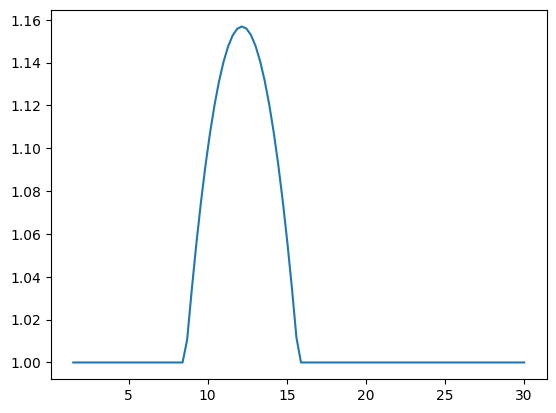

In [ ]:
plt.plot(z_T_multiplier, ratio_static_over_static_sc_opt, label="Static / Static Opt")